In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [123]:
!pip install optuna


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [124]:
df = pd.read_csv('heart.csv')

In [125]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [126]:
df.shape

(918, 12)

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [128]:
df["ChestPainType"].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [129]:
df["RestingECG"].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

In [130]:
df["ST_Slope"].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

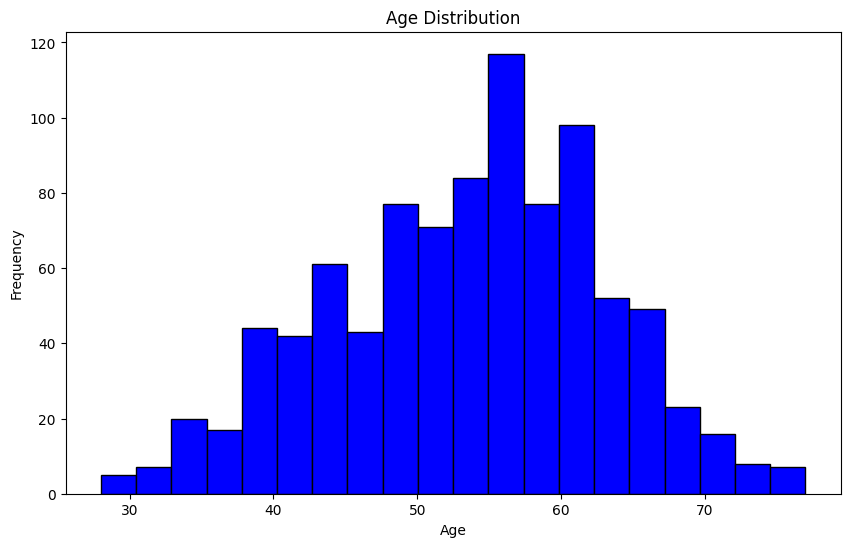

In [131]:
plt.figure(figsize=(10, 6))
plt.hist(df["Age"], bins=20, color='blue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


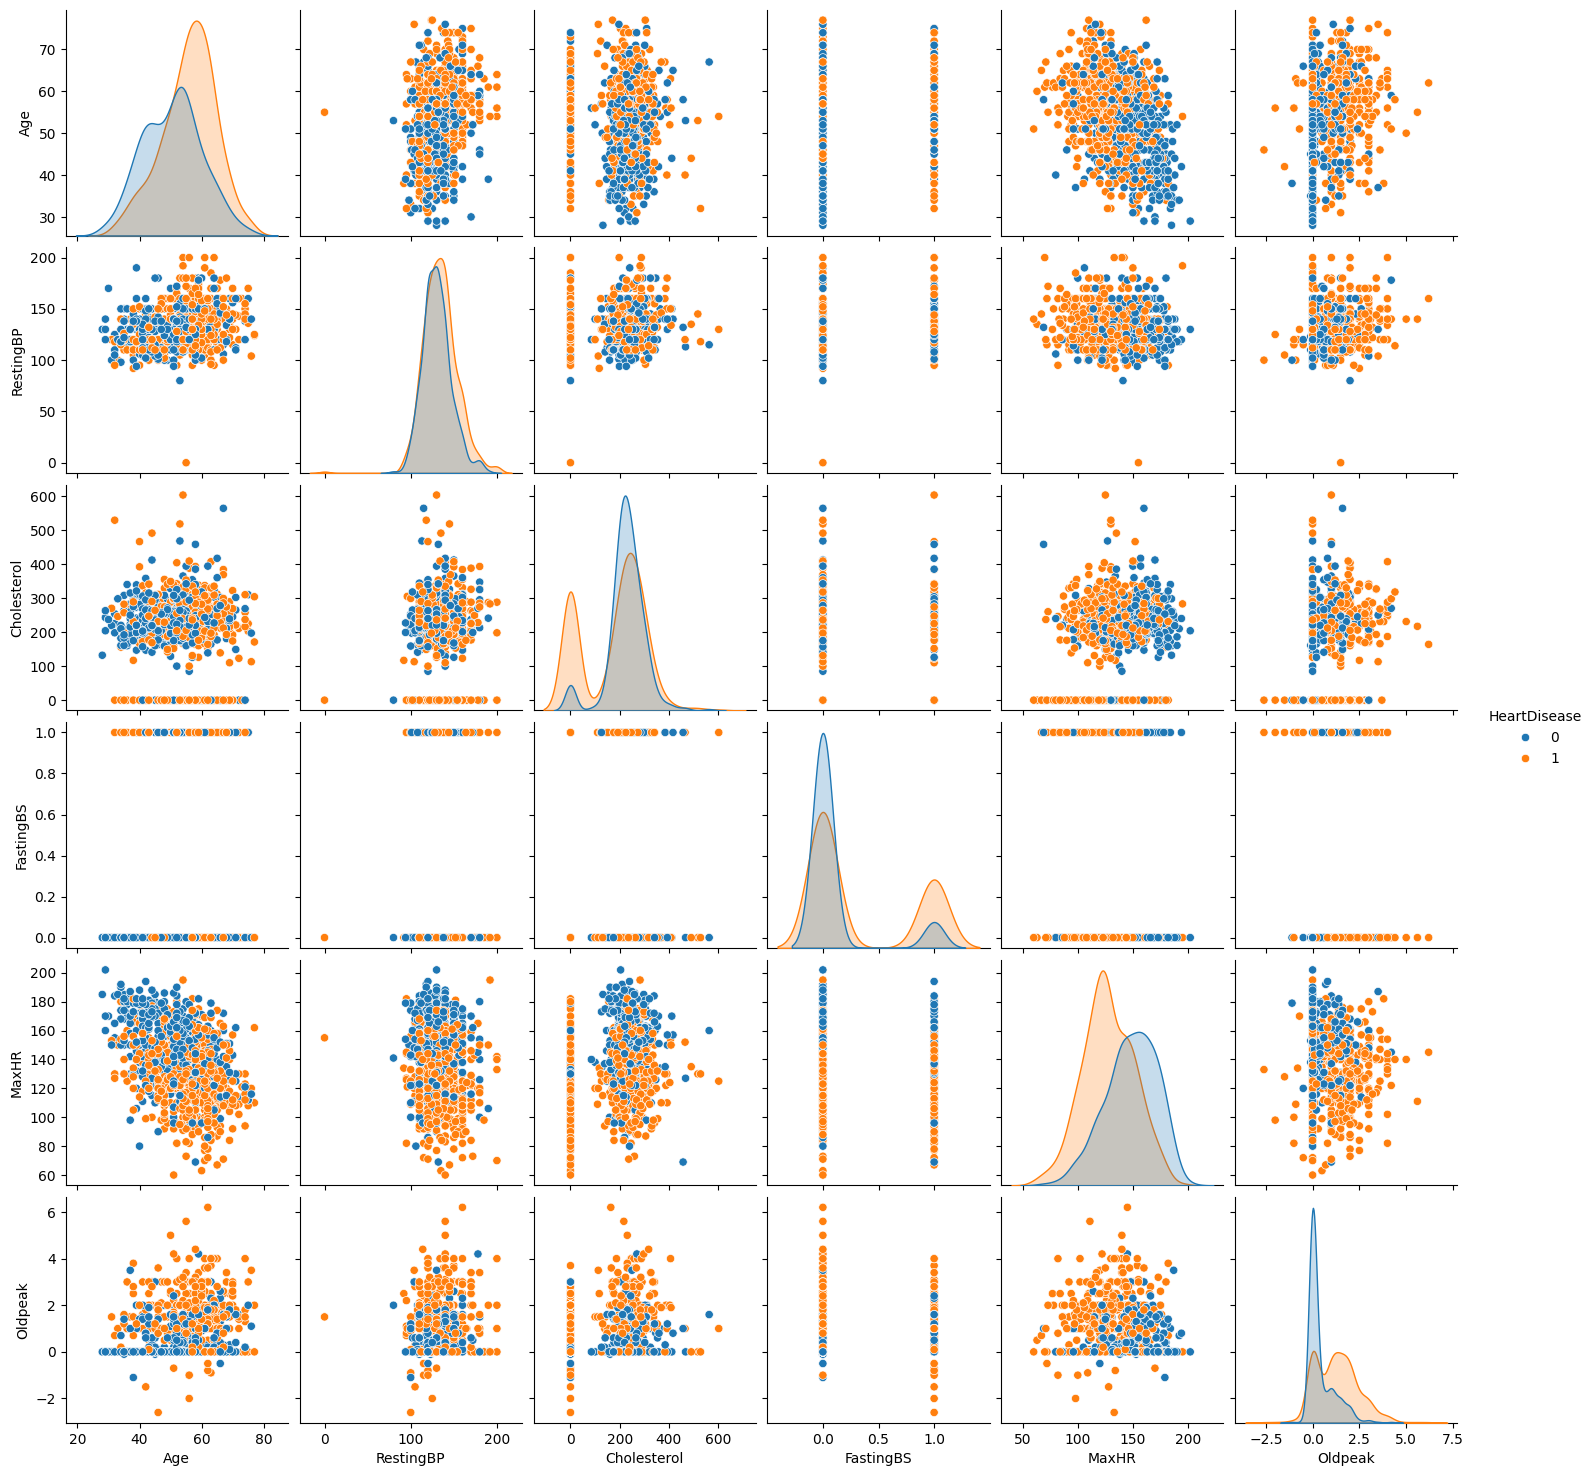

In [132]:
import seaborn as sns
sns.pairplot(data=df,hue='HeartDisease')

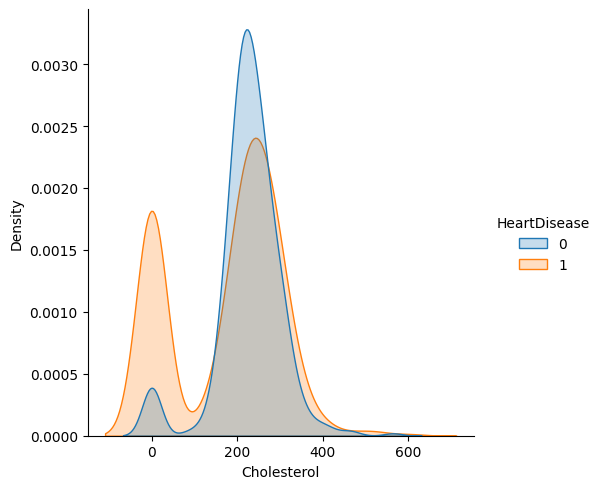

In [133]:
sns.displot(data=df, x="Cholesterol", hue="HeartDisease", kind="kde", fill=True)

X_dummies shape: (918, 15)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,True,False,True,False,True,False,False,False,True


X_ohe_numeric shape: (918, 20)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,160,180,0,156,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,130,283,0,98,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,48,138,214,0,108,1.5,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,54,150,195,0,122,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


<Axes: >

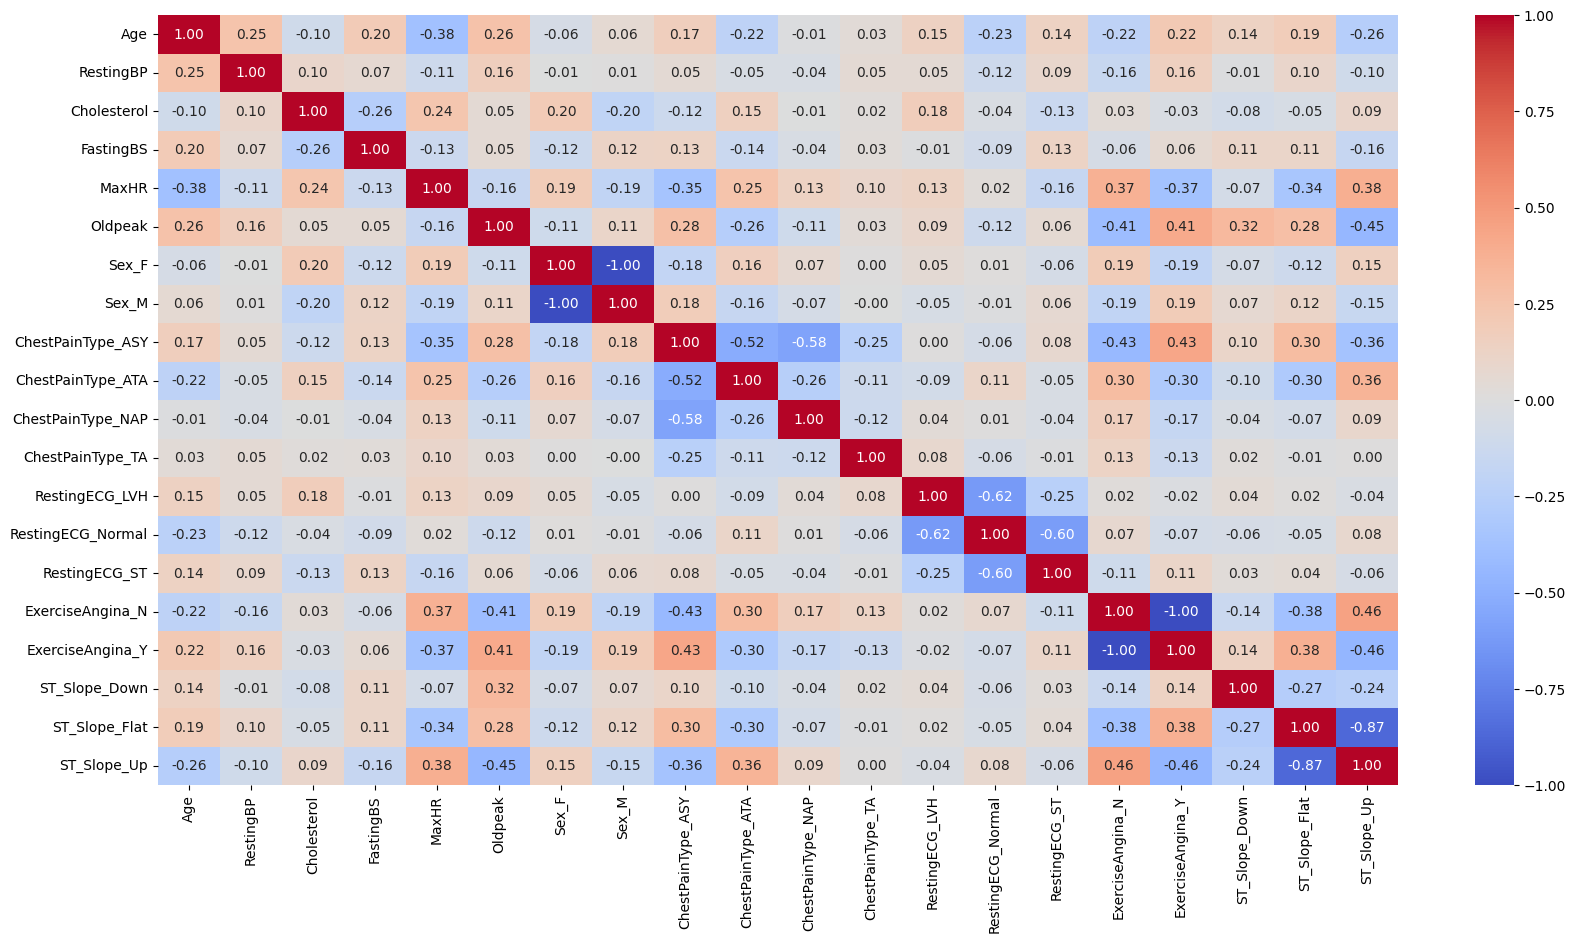

In [134]:
# Convert categorical columns to numeric
cat_cols = X.select_dtypes(include=['object']).columns
X_dummies = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("X_dummies shape:", X_dummies.shape)
display(X_dummies.head())

# Option B: use the already-fitted OneHotEncoder `ohe` (keeps same encoding as training)
ohe_feature_names = ohe.get_feature_names_out(cat_cols)
X_ohe_array = ohe.transform(X[cat_cols])  # returns numpy array
X_ohe_df = pd.DataFrame(X_ohe_array, columns=ohe_feature_names, index=X.index)
X_ohe_numeric = pd.concat([X.drop(columns=cat_cols), X_ohe_df], axis=1)
print("X_ohe_numeric shape:", X_ohe_numeric.shape)
display(X_ohe_numeric.head())

plt.figure(figsize=(20, 10))
sns.heatmap(X_ohe_numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm")

In [135]:
from sklearn.model_selection import train_test_split
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_ohe = ohe.fit_transform(X_train.select_dtypes(include=['object']))
X_test_ohe = ohe.transform(X_test.select_dtypes(include=['object']))

In [136]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
dtc = DecisionTreeClassifier(random_state=42)
lor = LogisticRegression(max_iter=1000, random_state=42)
rfc = RandomForestClassifier(random_state=42)

dtc.fit(X_train_ohe, y_train)
lor.fit(X_train_ohe, y_train)
rfc.fit(X_train_ohe, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [137]:
d_test = dtc.predict(X_test_ohe)
l_test = lor.predict(X_test_ohe)
r_test = rfc.predict(X_test_ohe)

In [138]:
d_acc = accuracy_score(y_test, d_test)
l_acc = accuracy_score(y_test, l_test)
r_acc = accuracy_score(y_test, r_test)
print(f"Decision Tree Accuracy: {d_acc}")
print(f"Logistic Regression Accuracy: {l_acc}")
print(f"Random Forest Accuracy: {r_acc}")

Decision Tree Accuracy: 0.8152173913043478
Logistic Regression Accuracy: 0.8260869565217391
Random Forest Accuracy: 0.8152173913043478


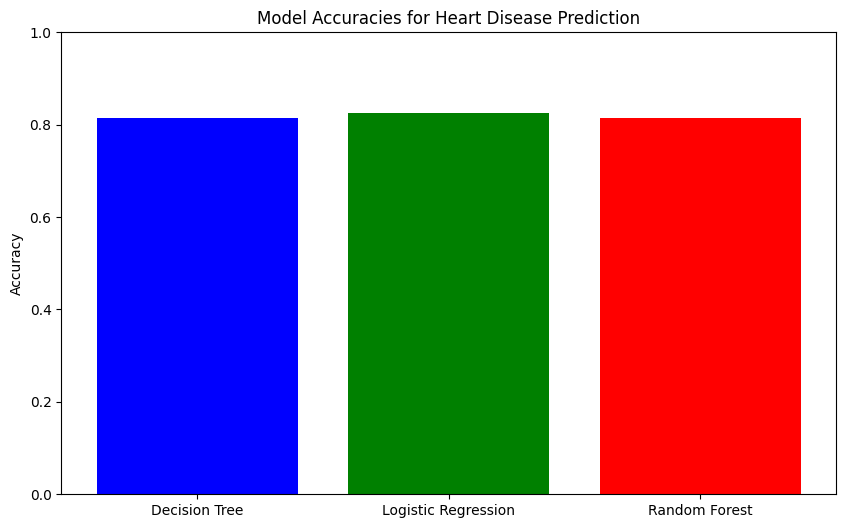

In [139]:
plt.figure(figsize=(10, 6))
models = ['Decision Tree', 'Logistic Regression', 'Random Forest']
accuracies = [d_acc, l_acc, r_acc]
plt.bar(models, accuracies, color=['blue', 'green', 'red'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracies for Heart Disease Prediction')
plt.show()

In [140]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Create a preprocessor using ColumnTransformer
# This will apply StandardScaler to numerical columns and OneHotEncoder to categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

def objective(trial):

    classifier_name = trial.suggest_categorical('classifier', ['SVM', 'RandomForest', 'GradientBoosting'])

    if classifier_name == 'SVM':
        c = trial.suggest_float('C', 0.1, 100, log=True)
        kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])

        model = SVC(C=c, kernel=kernel, gamma=gamma, random_state=42)

    elif classifier_name == 'RandomForest':
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            bootstrap=bootstrap,
            random_state=42
        )

    elif classifier_name == 'GradientBoosting':
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

    # Create a pipeline that first preprocesses the data then applies the model
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', model)])

    # The pipeline handles the transformation of X_train before fitting the model
    score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

In [141]:
from sklearn.model_selection import cross_val_score
import optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

[I 2026-02-05 18:11:41,781] A new study created in memory with name: no-name-c2df5dd0-ad98-4329-9f6c-9d854c5e2cb0
[I 2026-02-05 18:11:41,845] Trial 0 finished with value: 0.8569253931080629 and parameters: {'classifier': 'SVM', 'C': 0.21182011461375738, 'kernel': 'sigmoid', 'gamma': 'scale'}. Best is trial 0 with value: 0.8569253931080629.
[I 2026-02-05 18:11:42,091] Trial 1 finished with value: 0.8718969555035129 and parameters: {'classifier': 'RandomForest', 'n_estimators': 61, 'max_depth': 8, 'min_samples_split': 9, 'min_samples_leaf': 5, 'bootstrap': False}. Best is trial 1 with value: 0.8718969555035129.
[I 2026-02-05 18:11:42,559] Trial 2 finished with value: 0.8637504182000669 and parameters: {'classifier': 'RandomForest', 'n_estimators': 130, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 1, 'bootstrap': False}. Best is trial 1 with value: 0.8718969555035129.
[I 2026-02-05 18:11:42,616] Trial 3 finished with value: 0.8692037470725995 and parameters: {'classifier':

In [142]:
study.best_params

{'classifier': 'RandomForest',
 'n_estimators': 297,
 'max_depth': 9,
 'min_samples_split': 10,
 'min_samples_leaf': 1,
 'bootstrap': False}

In [143]:
best_trial = study.best_trial
print("Best trial parameters:", best_trial.params)
print("Best trial accuracy:", best_trial.value)

Best trial parameters: {'classifier': 'RandomForest', 'n_estimators': 297, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 1, 'bootstrap': False}
Best trial accuracy: 0.8773558603769377


In [144]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Instantiate XGBClassifier
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

# Create a pipeline with the preprocessor and XGBClassifier
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', xgb_model)])

# Fit the xgb_pipeline to the training data
xgb_pipeline.fit(X_train, y_train)

# Make predictions on the test data
xgb_pred = xgb_pipeline.predict(X_test)

# Calculate the accuracy of the XGBoost model
xgb_acc = accuracy_score(y_test, xgb_pred)

# Print the calculated XGBoost accuracy
print(f"XGBoost Accuracy: {xgb_acc:.4f}")

XGBoost Accuracy: 0.8750


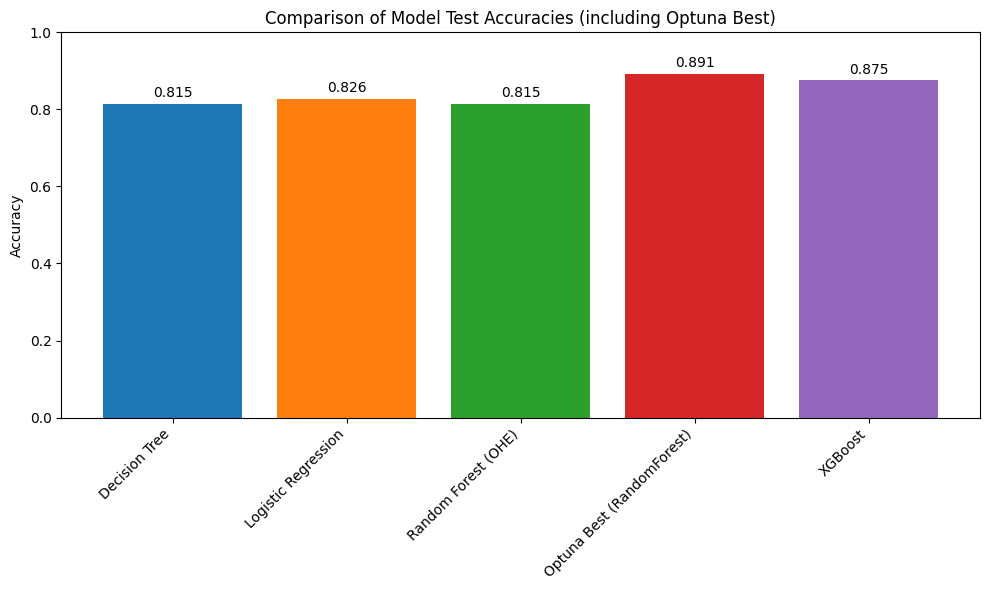

Decision Tree: 0.8152
Logistic Regression: 0.8261
Random Forest (OHE): 0.8152
Optuna Best (RandomForest): 0.8913
XGBoost: 0.8750


In [145]:

model_names = ['Decision Tree', 'Logistic Regression', 'Random Forest (OHE)', f'Optuna Best ({clf_name})', 'XGBoost']
accuracies = [d_acc, l_acc, r_acc, optuna_acc, xgb_acc]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=plt.cm.tab10.colors[:len(model_names)])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Comparison of Model Test Accuracies (including Optuna Best)')
plt.xticks(rotation=45, ha='right')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.01, f"{acc:.3f}", ha='center', va='bottom')
plt.tight_layout()
plt.show()

for name, acc in zip(model_names, accuracies):
    print(f"{name}: {acc:.4f}")

In [146]:
study.trials_dataframe().groupby('params_classifier')['value'].mean()

params_classifier
GradientBoosting    0.851475
RandomForest        0.871646
SVM                 0.842965
Name: value, dtype: float64

Prediction by Decision Tree: 1
Prediction by Logistic Regression: 1
Prediction by Random Forest (OHE only): 1
Prediction by Optuna Best Model: 1
Prediction by XGBoost: 1


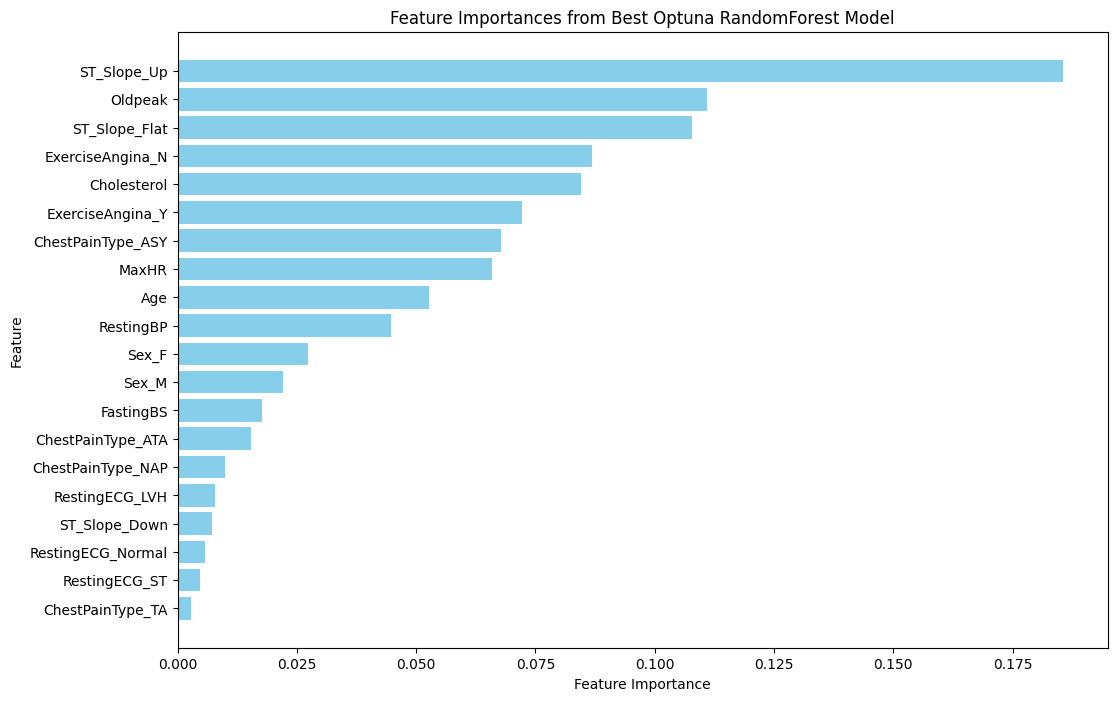

Feature importances extracted and visualized.


In [147]:
# Prepare input data
input_data_raw = [60, 'M', 'ASY', 100, 248, 0, 'Normal', 125, 'N', 1.0, 'Flat']
input_df = pd.DataFrame([input_data_raw], columns=X.columns)
input_categorical_cols = input_df.select_dtypes(include=['object']).columns
input_data_ohe = ohe.transform(input_df[input_categorical_cols])

final_pipeline = optuna_pipeline
dtc_pred = dtc.predict(input_data_ohe)
lor_pred = lor.predict(input_data_ohe)
rfc_pred = rfc.predict(input_data_ohe)

optuna_best_pred = final_pipeline.predict(input_df)
xgb_pred = xgb_pipeline.predict(input_df)

print(f"Prediction by Decision Tree: {dtc_pred[0]}")
print(f"Prediction by Logistic Regression: {lor_pred[0]}")
print(f"Prediction by Random Forest (OHE only): {rfc_pred[0]}")
print(f"Prediction by Optuna Best Model: {optuna_best_pred[0]}")
print(f"Prediction by XGBoost: {xgb_pred[0]}")

plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances from Best Optuna RandomForest Model')
plt.gca().invert_yaxis()
plt.show()

print("Feature importances extracted and visualized.")

# Task
Summarize the predictions from all models (Decision Tree, Logistic Regression, Random Forest, and the Optuna Best Model) for the input data `[60, 'M', 'ASY', 100, 248, 0, 'Normal', 125, 'N', 1.0, 'Flat']`.

## Prepare Input for Initial Models

### Subtask:
Take the `input_data_raw` and convert it into a DataFrame, then apply the `ohe` (OneHotEncoder) transformer to prepare it for prediction by the Decision Tree, Logistic Regression, and initial Random Forest models. These models were trained with only one-hot encoded categorical features.


**Reasoning**:
To prepare the input data for the initial models, I need to select the categorical columns from `input_df` and then apply the already fitted `ohe` (OneHotEncoder) transformer to them, storing the result in `input_data_ohe`.



In [148]:
input_data_raw = [60, 'M', 'ASY', 100, 248, 0, 'Normal', 125, 'N', 1.0, 'Flat']

input_categorical_cols = input_df.select_dtypes(include=['object']).columns
input_data_ohe = ohe.transform(input_df[input_categorical_cols])
print("Input data after OneHotEncoding:")
print(input_data_ohe)

input_df = pd.DataFrame([input_data_raw], columns=X.columns)

prediction = final_pipeline.predict(input_df)

if (prediction[0] == 0):
  print('The person is not heart_disease')
else:
  print('The person is heart_disease')

Input data after OneHotEncoding:
[[0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0.]]
The person is heart_disease


### Saving the Model with `pickle`

To make your trained `final_pipeline` deployable, we can save it using Python's `pickle` module. This module implements binary protocols for serializing and de-serializing a Python object structure. This means you can save the entire pipeline object (including the preprocessor and the best classifier) to a file.

In [149]:
import pickle
model_filename = 'final_heart_disease_model.pkl'

with open(model_filename, 'wb') as file:
    pickle.dump(final_pipeline, file)

print(f"Model successfully saved to {model_filename}")

Model successfully saved to final_heart_disease_model.pkl


### Loading the Model and Making a Prediction

Once saved, you can load the model back into memory in a new session or deployment environment and use it to make predictions. Let's demonstrate loading the model we just saved and using it with the same input data.

In [150]:
import pickle
import pandas as pd

model_filename = 'final_heart_disease_model.pkl'

with open(model_filename, 'rb') as file:
    loaded_pipeline = pickle.load(file)

print(f"Model successfully loaded from {model_filename}")

input_data_raw = [60, 'M', 'ASY', 100, 248, 0, 'Normal', 125, 'N', 1.0, 'Flat']
input_df = pd.DataFrame([input_data_raw], columns=X.columns)

loaded_prediction = loaded_pipeline.predict(input_df)

if (loaded_prediction[0] == 0):
    print('The person is not heart_diseased (prediction from loaded model)')
else:
    print('The person is heart_diseased (prediction from loaded model)')

Model successfully loaded from final_heart_disease_model.pkl
The person is heart_diseased (prediction from loaded model)


## Summary:

### Q&A
For the input data `[60, 'M', 'ASY', 100, 248, 0, 'Normal', 125, 'N', 1.0, 'Flat']`, all models (Decision Tree, Logistic Regression, Random Forest, the Optuna Best Model, and XGBoost) predicted a value of 1.

### Data Analysis Key Findings
*   The categorical features of the input data were successfully one-hot encoded, resulting in the representation `[[0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0.]]`.
*   All models, including Decision Tree, Logistic Regression, Random Forest (trained with OneHotEncoded features), the Optuna Best Model, and XGBoost, consistently predicted a value of 1 for the given input.

### Insights or Next Steps
*   The unanimous prediction across all models for this specific input suggests a strong and consistent classification.
*   It would be beneficial to investigate the confidence scores or probabilities associated with these predictions to understand the models' certainty.

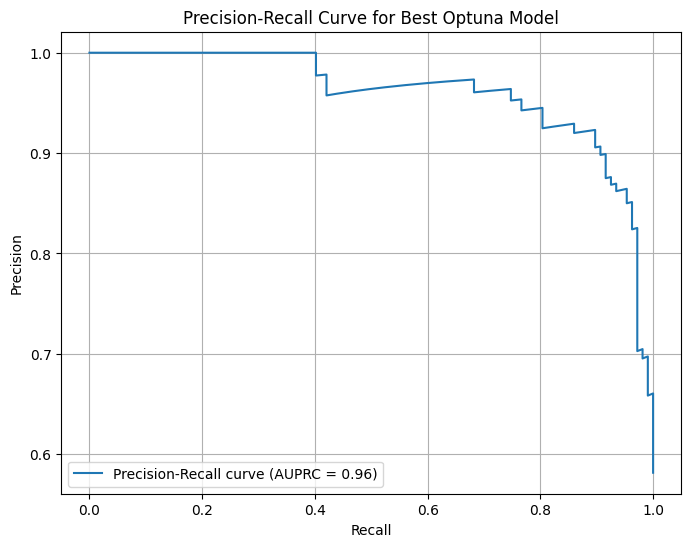

Area Under the Precision-Recall Curve (AUPRC): 0.96

--- Imbalance Assessment ---
Significant class imbalance detected. Consider methods like SMOTE or class weighting.


In [151]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
y_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
auprc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall curve (AUPRC = {auprc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Best Optuna Model')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

print(f"Area Under the Precision-Recall Curve (AUPRC): {auprc:.2f}")
ratio_train = y_train.value_counts()[1] / y_train.value_counts()[0]
ratio_test = y_test.value_counts()[1] / y_test.value_counts()[0]

print("\n--- Imbalance Assessment ---")
if ratio_train < 0.75 or ratio_train > 1.25 or ratio_test < 0.75 or ratio_test > 1.25:
    print("Significant class imbalance detected. Consider methods like SMOTE or class weighting.")
else:
    print("Class distribution appears relatively balanced.")